# **Project title: End to End ML pipeline Customer Churn**

# Submitted By: Afeera Sagheer

# **Project Description:**
This project develops an end-to-end Machine Learning pipeline to predict customer churn and identify customers who are likely to leave a business. The pipeline covers the complete ML workflow, including data collection, data preprocessing, exploratory data analysis (EDA), feature engineering, model training, evaluation, and deployment. Customer data is cleaned and transformed before training classification models to predict churn behavior. The trained model is then integrated into an interactive application, enabling users to input customer information and receive real-time churn predictions. This solution helps businesses improve customer retention strategies, reduce revenue loss, and make data-driven decisions.

# **1_ Importing Libraries**

In [1]:
# pandas for data cleaning and manipulation
import pandas as pd
# numpy for numerical and statistical operations
import numpy as np
# matplotlib for visualization
import matplotlib.pyplot as plt
# seaborn for advanced visualization
import seaborn as sns

# train test split for seperating training and testing data
from sklearn.model_selection import train_test_split
# pipeline for combining multiple steps
from sklearn.pipeline import Pipeline
# column transformer for applying different techniques to a column
from sklearn.compose import ColumnTransformer
# one hotEncoder for converting text to numbers and standard scalar for balancing values
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# simple imputer to fill missing values
from sklearn.impute import SimpleImputer
# logistic regression is a classifier model
from sklearn.linear_model import LogisticRegression
# random forest is also for classification
from sklearn.ensemble import RandomForestClassifier
# its used for cross validation
from sklearn.model_selection import GridSearchCV
# classification report and confusion matrix for model evaluation
from sklearn.metrics import classification_report, confusion_matrix
# Joblib to train nad store dataset
import joblib
# accuracy score for checking model efficiency
from sklearn.metrics import accuracy_score


# **2_ Loading Dataset**

In [2]:
# mounting drive and loading dataset
churn_df = pd.read_csv(
    "/content/drive/MyDrive/Telco_Churn_Dataset.csv"
)

churn_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **3_ Data Inspection**

In [29]:
# checking numbers of rows and columns
print(churn_df.shape)


(7043, 21)


In [32]:
# checking number of enteries
churn_df.size

147903

In [33]:
# checking percentile, mean ,median, std
churn_df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441,0.265370
std,0.368612,24.559481,30.090047,2266.771362,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [34]:
# checking column names
churn_df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [35]:
# checking dtypes
churn_df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [30]:
# checking not null enteries , value counts and datatypes
print(churn_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [36]:
# checking value counts
churn_df.value_counts()

,,,,,,,,,,,,,,,,,,,,,count
customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,
9995-HOTOH,Male,0,Yes,Yes,63,No,No phone service,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Electronic check,59.00,3707.60,0,1
0002-ORFBO,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,0,1
0003-MKNFE,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,0,1
0004-TLHLJ,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,1,1
0011-IGKFF,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0018-NYROU,Female,0,Yes,No,5,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,68.95,351.50,0,1
0017-IUDMW,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),116.80,8456.75,0,1
0017-DINOC,Male,0,No,No,54,No,No phone service,DSL,Yes,No,No,Yes,Yes,No,Two year,No,Credit card (automatic),45.20,2460.55,0,1


In [37]:
#  checking unique values
churn_df.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


# **4_ Data Cleaning**

In [31]:
# checking values that are null in each column
print(churn_df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [38]:
# checking null values in whole dataset
churn_df.isnull()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7039,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7040,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7041,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [39]:
#checking not null values in whole dataset
churn_df.notnull()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
7039,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
7040,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
7041,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True


In [41]:
# checking not null values in each column
churn_df.notnull().sum()

,0
customerID,7043
gender,7043
SeniorCitizen,7043
Partner,7043
Dependents,7043
tenure,7043
PhoneService,7043
MultipleLines,7043
InternetService,7043
OnlineSecurity,7043


In [42]:
# it drops irrelevant columns
churn_df = churn_df.drop(
    ["customerID"],
    axis=1
)


In [43]:
# it fills missing values
churn_df.interpolate()

/tmp/ipykernel_3263/642655081.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  churn_df.interpolate()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


In [4]:
churn_df["TotalCharges"] = pd.to_numeric(
    churn_df["TotalCharges"],
    errors="coerce"
)

In [5]:
churn_df["Churn"] = churn_df["Churn"].map(
    {
        "Yes":1,
        "No":0
    }
)

# **5_ Numerical Operations**

In [45]:
# checking average in each column
churn_df.mean(numeric_only = True)


,0
SeniorCitizen,0.162147
tenure,32.371149
MonthlyCharges,64.761692
TotalCharges,2283.300441
Churn,0.265370


In [46]:
# average of whole dataset
churn_df.mean(numeric_only = True).sum()

np.float64(2380.8607986439383)

In [47]:
# middle value of each column
churn_df.median(numeric_only = True)

,0
SeniorCitizen,0.000
tenure,29.000
MonthlyCharges,70.350
TotalCharges,1397.475
Churn,0.000


In [48]:
# median of whole dataset
churn_df.median(numeric_only = True).sum()

np.float64(1496.8249999999998)

In [50]:
# checking spread of values from mean in each column
churn_df.std(numeric_only = True)

,0
SeniorCitizen,0.368612
tenure,24.559481
MonthlyCharges,30.090047
TotalCharges,2266.771362
Churn,0.441561


In [51]:
# spread of values in whole dataset
churn_df.std(numeric_only = True).sum()

np.float64(2322.23106291465)

In [52]:
# square of std in each column
churn_df.var(numeric_only = True)

,0
SeniorCitizen,1.358745e-01
tenure,6.031681e+02
MonthlyCharges,9.054109e+02
TotalCharges,5.138252e+06
Churn,1.949764e-01


In [53]:
# square of std in whole dataset
churn_df.var(numeric_only = True).sum()

np.float64(5139761.316946937)

In [54]:
# maximum value in each column
churn_df.max(numeric_only = True)

,0
SeniorCitizen,1.00
tenure,72.00
MonthlyCharges,118.75
TotalCharges,8684.80
Churn,1.00


In [55]:
# maximum value in whole dataset
churn_df.max(numeric_only = True).sum()

np.float64(8877.55)

In [56]:
# minimum value in each column
churn_df.min(numeric_only = True)

,0
SeniorCitizen,0.00
tenure,0.00
MonthlyCharges,18.25
TotalCharges,18.80
Churn,0.00


In [57]:
# minimum value in whole dataset
churn_df.min(numeric_only = True).sum()

np.float64(37.05)

# **6_ Hnadling Numeric and Categorical Values**

In [49]:
# seperating numerical and categorical features
numerical_features = X.select_dtypes(
    include=["int64","float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print(numerical_features)
print(categorical_features)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [62]:
# manipulating numeric values
numeric_transformer = Pipeline(
    steps=[
         # inputer for filling missing values
          ("imputer", SimpleImputer(strategy="median")),
         # scalar for balancing values
          ("scaler", StandardScaler())])

In [63]:
# manipulating categorical values
categorical_transformer = Pipeline(
    # imputer for filling missing values
    steps=[("imputer",SimpleImputer(strategy="most_frequent")),
        # encoder to convert text to numeric
         ("encoder",OneHotEncoder(handle_unknown="ignore" ))])

# **7_ Column Transformer**

In [65]:
# applying features to columns
preprocessor = ColumnTransformer(
    transformers=[("num",numeric_transformer,numerical_features),
        ("cat",categorical_transformer,categorical_features )])

# **8_ Train Teat Split**

In [66]:
# seperating training and testing data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# **9_ Logistic Regression**

In [71]:
# creating logistic pipeline
logistic_pipeline = Pipeline(
    steps=[("preprocessor",preprocessor),("classifier", LogisticRegression(max_iter=1000))])

In [72]:
# training model
logistic_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

# **10_ Taking Predictions**

In [74]:
# taking predictions
y_pred = logistic_pipeline.predict(X_test)
# checking accuracy
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
print(classification_report(y_test,y_pred))

Accuracy: 0.8211497515968772
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



# **11_ Model Evaluation**

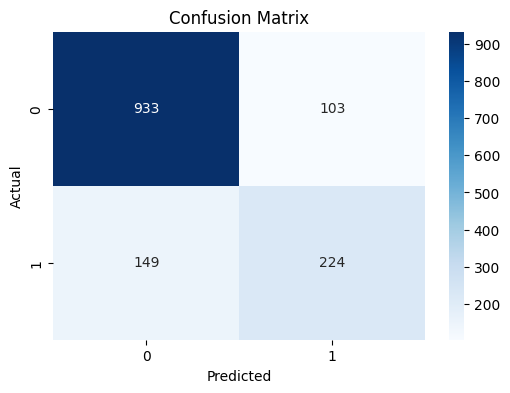

In [75]:
# confusion matrix
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **12_ Random Forest**

In [76]:
# creating random forest pipeline
rf_pipeline = Pipeline(
    steps=[("preprocessor",preprocessor),("classifier",RandomForestClassifier(random_state=42))])

In [77]:
param_grid = {"classifier__n_estimators":[100,200],"classifier__max_depth":[5,10,None],"classifier__min_samples_split":[2,5]}

In [78]:
# training model
grid_search = GridSearchCV(estimator=rf_pipeline,param_grid=param_grid,cv=3,scoring="accuracy",n_jobs=-1)
grid_search.fit(X_train,y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('e...
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [5, 10, None],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [100, 200]},
             scoring='accuracy')

In [19]:
# priniting best parameters and best score
print(grid_search.best_params_)
print(grid_search.best_score_)

{'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
0.8036918707845225


In [79]:
# taking predictions
best_model = grid_search.best_estimator_y_pred_rf = best_model.predict(X_test)
# model evaluation
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.73      0.79      0.76      1036
           1       0.25      0.20      0.22       373

    accuracy                           0.63      1409
   macro avg       0.49      0.49      0.49      1409
weighted avg       0.60      0.63      0.62      1409



# **13_ joblib**

In [21]:
# saving pipeline
joblib.dump(best_model,"customer_churn_pipeline.pkl")
print("Pipeline Saved Successfully")

Pipeline Saved Successfully


In [81]:
loaded_model = joblib.load("customer_churn_pipeline.pkl")

In [80]:
prediction = loaded_model.predict(X_test.iloc[[0]])
print("Prediction:",prediction)

Prediction: [1]


# **14_Visualization**

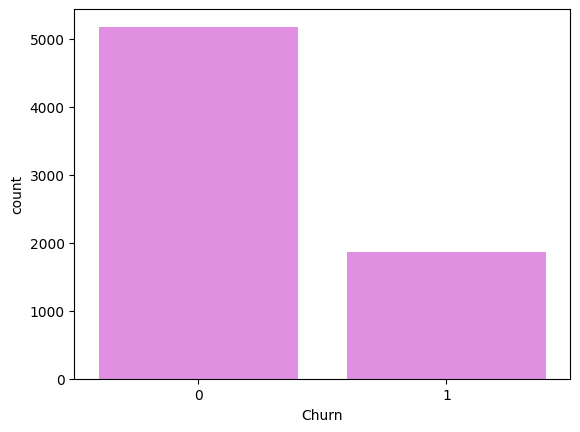

In [82]:
sns.countplot(x="Churn",data=churn_df, color = "violet")
plt.show()

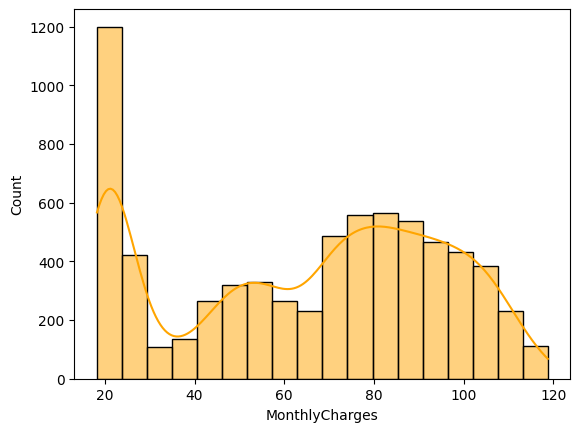

In [83]:
sns.histplot(churn_df["MonthlyCharges"],kde=True, color = 'orange')
plt.show()

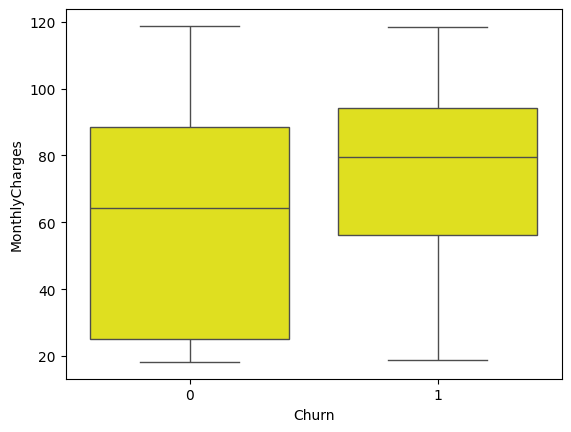

In [84]:
sns.boxplot(x="Churn",y="MonthlyCharges",data=churn_df, color = 'yellow')
plt.show()

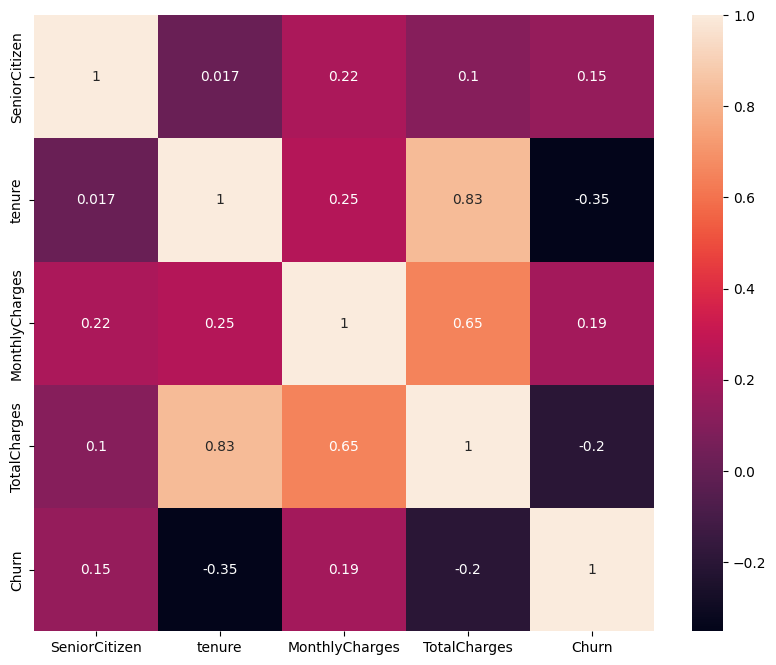

In [85]:
plt.figure(figsize=(10,8))
sns.heatmap(churn_df.select_dtypes(include=np.number).corr(),annot=True)
plt.show()

In [86]:
new_customer = {
    "gender": "Male",
    "SeniorCitizen": 1,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 24,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "DSL",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 70.0,
    "TotalCharges": 1800.0
}
new_df = pd.DataFrame([new_customer])
print(new_df)
prediction = loaded_model.predict(new_df)
print(prediction)

  gender  SeniorCitizen Partner Dependents  tenure PhoneService MultipleLines  \
0   Male              1     Yes         No      24          Yes            No   

  InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport  \
0             DSL             No          Yes               No          No   

  StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No              No  Month-to-month              Yes   

      PaymentMethod  MonthlyCharges  TotalCharges  
0  Electronic check            70.0        1800.0  
[0]
